In [14]:
import os.path as osp

import torch
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.nn import GCNConv

dataset = 'Cora'
path = osp.abspath(osp.join('..', 'data', 'Planetoid'))
dataset = Planetoid(path, dataset)
data = dataset[0]
dataset.num_classes

7

In [11]:
data.edge_index

tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])

In [15]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN().to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for _ in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()



In [16]:
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='log_probs',
    ),
)
node_index = 10
explanation = explainer(data.x, data.edge_index, index=node_index)
print(f'Generated explanations in {explanation.available_explanations}')

path = 'feature_importance.png'
explanation.visualize_feature_importance(path, top_k=10)
print(f"Feature importance plot has been saved to '{path}'")

path = 'subgraph.pdf'
explanation.visualize_graph(path)
print(f"Subgraph visualization plot has been saved to '{path}'")

Generated explanations in ['edge_mask', 'node_mask']
Feature importance plot has been saved to 'feature_importance.png'
Subgraph visualization plot has been saved to 'subgraph.pdf'


In [18]:
explanation['node_mask']

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')

In [13]:
import pandas as pd
import os
os.chdir("/home/mabarr/TCruzi_pipeline/")

data = pd.read_csv("external/grover/solubility_data/solubility_data_categorized.csv")

data

,SMILES,logS_category
0,COC1=C(OC)C(=O)C(=C(C1=O)C/C=C(/CC/C=C(/CC/C=C...,0
1,CCCCCCCCCCCCCCCCCC(=O)Nc1ccc(cc1)NC(=O)CCCCCCC...,0
2,CCCCCCCCCCCCCCCC(=O)OCCCCOC(=O)CCCCCCCCCCCCCCC,0
3,CCCC[Sn](S[Sn](CCCC)(CCCC)CCCC)(CCCC)CCCC,0
4,CCCCCCCCCCCCCCCCOP(=O)(OCCCCCCCCCCCCCCCC)O,0
...,...,...
16017,C1=CC=C2C=C(C=CC2=C1)[As](=O)(O)O,1
16018,COP(=S)(OC)SCC1=NC(=NC(=N1)N)N,0
16019,CC(=O)N[C@@H](CC1=CC(=C(C(=C1)Br)O)Br)C(=O)O,1
16020,CN1/C(=C(\NC2=CC=CC=N2)/O)/C(=O)C3=CC=CC=C3S1(...,0


In [44]:
import os
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from task.train import load_data
os.chdir("/home/mabarr/TCruzi_pipeline/")
from argparse import Namespace

args = Namespace(
    data_path="external/grover/solubility_data/solubility_data_categorized.csv",
    save_dir="model_nofeatures_category",
    checkpoint_path="external/grover/checkpoints/grover_large.pt",
    checkpoint_dir = "model_nofeatures_category",
    checkpoint_paths = ["model_nofeatures_category/fold_0/model_0/model.pt"],
    dataset_type="classification",
    split_type="scaffold_balanced",
    split_sizes=[0.7, 0.15, 0.15],
    metric="accuracy",
    ensemble_size=1,
    num_folds=1,
    ffn_hidden_size=200,
    batch_size=1,
    epochs=60,
    init_lr=0.00015,
    self_attention=True,
    save_smiles_splits=True,
    use_wandb=True,
    wandb_entity="mariabar",
    num_workers=50,
    dropout=0.1,
    ffn_num_layers=1,
    features_path = None,
    max_data_size = None,
    use_compound_names = None,
    seed = 0,
    separate_test_path = None,
    separate_val_path = None,
    folds_file = None,
    val_fold_index = None,
    test_fold_index = None,
    features_scaling=False,
    bond_drop_rate = 0,
    no_cache = True,
    cuda = True,
)

debug = info = print
logger = None

In [15]:
len(train_data)

11215

In [16]:
item = train_data[0]

print(type(item))
print(item)
print(item.__dict__)

<class 'grover.data.moldataset.MoleculeDatapoint'>
{'features_generator': None, 'args': Namespace(batch_size=128, bond_drop_rate=0, checkpoint_path='external/grover/checkpoints/grover_large.pt', data_path='external/grover/solubility_data/solubility_data_categorized.csv', dataset_type='classification', dropout=0.1, ensemble_size=1, epochs=60, features_dim=0, features_path=None, features_scaling=False, features_size=None, ffn_hidden_size=200, ffn_num_layers=1, folds_file=None, init_lr=0.00015, max_data_size=None, metric='accuracy', no_cache=True, num_folds=1, num_tasks=1, num_workers=50, save_dir='model_nofeatures_category_dropout01', save_smiles_splits=True, seed=0, self_attention=True, separate_test_path=None, separate_val_path=None, split_sizes=[0.7, 0.15, 0.15], split_type='scaffold_balanced', task_names=['logS_category'], test_fold_index=None, train_data_size=11215, use_compound_names=None, use_wandb=True, val_fold_index=None, wandb_entity='mariabar'), 'features': None, 'compound_na

In [4]:
from torch.utils.data import DataLoader
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from grover.data import MolCollator
mol_collator = MolCollator(shared_dict={}, args=args)
train_loader = DataLoader(train_data,
                        batch_size=1,
                        shuffle=True,
                        num_workers=args.num_workers,
                        collate_fn=mol_collator)

In [3]:
_, batch, features_batch, mask, targets = next(iter(train_loader))

In [ ]:
_, batch, features_batch, mask, targets = next(iter(train_loader))
f_atoms, f_bonds, a2b, b2a, b2revb, a_scope, b_scope, a2a = batch

In [74]:
f_atoms.shape
a_scope

tensor([[ 1, 11]])

In [ ]:

print(a2b)
print(b2a)
print(b2revb)
print(a2a)


tensor([[ 0,  0,  0],
        [ 2,  4,  0],
        [ 1,  6,  8],
        [ 5, 10,  0],
        [ 9, 12, 14],
        [11, 16, 18],
        [ 3, 15, 20],
        [19, 22,  0],
        [21,  0,  0],
        [17,  0,  0],
        [13,  0,  0],
        [ 7,  0,  0]])
tensor([ 0,  1,  2,  1,  6,  2,  3,  2, 11,  3,  4,  4,  5,  4, 10,  5,  6,  5,
         9,  6,  7,  7,  8])
tensor([ 0,  2,  1,  4,  3,  6,  5,  8,  7, 10,  9, 12, 11, 14, 13, 16, 15, 18,
        17, 20, 19, 22, 21])
tensor([[ 0,  0,  0],
        [ 2,  6,  0],
        [ 1,  3, 11],
        [ 2,  4,  0],
        [ 3,  5, 10],
        [ 4,  6,  9],
        [ 1,  5,  7],
        [ 6,  8,  0],
        [ 7,  0,  0],
        [ 5,  0,  0],
        [ 4,  0,  0],
        [ 2,  0,  0]])


In [98]:
a_scope

edge_idx.shape

torch.Size([2, 23])

In [64]:
b2revb

tensor([ 0,  2,  1,  4,  3,  6,  5,  8,  7, 10,  9, 12, 11, 14, 13, 16, 15, 18,
        17, 20, 19, 22, 21])

In [ ]:
def grover_to_pyg(b2a, b2revb):

    edge_index = torch.stack([
        b2a,
        b2a[b2revb]
    ])

    #edge_index = edge_index[:, 1:] # ignoring padding entry in GROVER

    return edge_index

def pyg_to_grover(edge_index):
    b2a = edge_index[0,:]
    b2revb = []
    a2b = []

    for i in range(edge_index.shape[1]):
        target = edge_index[0,i]
        source = edge_index[1,i]
        idx = torch.where(
            (edge_index[0] == source) &
            (edge_index[1] == target)
        )[0]
        b2revb.append(idx.item())

    for atom in set(edge_idx[0, :].tolist()):
        incoming = torch.where(edge_idx[1, :] == atom)[0]
        a2b.append(incoming)

    max_bonds = max(len(row) for row in a2b)
    a2b = torch.stack([
        torch.cat([
            row, 
            torch.zeros(max_bonds - len(row), dtype=torch.long)
        ])
        for row in a2b
    ])
    
    a2a = torch.zeros_like(a2b)

    for atom in range(a2b.shape[0]):
        bonds = a2b[atom]
        a2a[atom] = edge_index[0, bonds]

    return b2a, torch.tensor(b2revb), a2b, a2a



In [94]:
edge_idx = grover_to_pyg(b2a, b2revb)

edge_idx

tensor([[ 0,  1,  2,  1,  6,  2,  3,  2, 11,  3,  4,  4,  5,  4, 10,  5,  6,  5,
          9,  6,  7,  7,  8],
        [ 0,  2,  1,  6,  1,  3,  2, 11,  2,  4,  3,  5,  4, 10,  4,  6,  5,  9,
          5,  7,  6,  8,  7]])

In [99]:
b2a, b2revb, a2b, a2a = pyg_to_grover(edge_idx)

In [ ]:
import torch
import torch.nn as nn


class GroverAdapter(nn.Module):
    def __init__(self, grover_model):
        super().__init__()
        self.grover = grover_model

    def pyg_to_grover(self, x, edge_index, edge_attr):
   
        f_atoms = x
        f_bonds = edge_attr

        # Source atom of each directed bond
        b2a = edge_index[0]

        b2revb = torch.empty(
            edge_index.shape[1],
            dtype=torch.long,
            device=edge_index.device
        )

        for i in range(edge_index.shape[1]):
            source = edge_index[0, i]
            target = edge_index[1, i]

            reverse = torch.where(
                (edge_index[0] == target) &
                (edge_index[1] == source)
            )[0]

            b2revb[i] = reverse[0]

        num_atoms = x.shape[0]-1

        a2b_list = []

        for atom in range(num_atoms):
            incoming = torch.where(edge_index[1] == atom)[0]
            a2b_list.append(incoming)

        max_bonds = max(len(row) for row in a2b_list)

        a2b = torch.stack([
            torch.cat([
                row,
                torch.zeros(
                    max_bonds - len(row),
                    dtype=torch.long,
                    device=edge_index.device
                )
            ])
            for row in a2b_list
        ])

        a2a = torch.zeros_like(a2b)

        for atom in range(num_atoms):
            bonds = a2b[atom]
            a2a[atom] = edge_index[0, bonds]

        a_scope = [(1, num_atoms)]
        b_scope = [(1, edge_index.shape[1]-1)]

        return (
            f_atoms,
            f_bonds,
            a2b,
            b2a,
            b2revb,
            a_scope,
            b_scope,
            a2a,
        )

    def forward(self, x, edge_index, edge_attr):
        batch = self.pyg_to_grover(
            x,
            edge_index,
            edge_attr
        )

        output = self.grover(
            batch,
            [None]
        )

        return output

In [5]:
smiles, batch, features_batch, mask, targets = next(iter(train_loader))

In [51]:
smiles

['Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1']

In [2]:
import os 
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from task.predict import make_predictions
os.chdir("/home/mabarr/TCruzi_pipeline/")

from argparse import Namespace

args = Namespace(
    data_path="external/grover/solubility_data/solubility_data_categorized.csv",
    save_dir="model_nofeatures_category",
    checkpoint_dir = "model_nofeatures_category",
    checkpoint_paths = ["model_nofeatures_category/fold_0/model_0/model.pt"],
    dataset_type="classification",
    split_type="scaffold_balanced",
    split_sizes=[0.7, 0.15, 0.15],
    metric="accuracy",
    ensemble_size=1,
    num_folds=1,
    ffn_hidden_size=200,
    batch_size=1,
    epochs=60,
    init_lr=0.00015,
    self_attention=True,
    save_smiles_splits=True,
    use_wandb=True,
    wandb_entity="mariabar",
    num_workers=50,
    dropout=0.1,
    ffn_num_layers=1,
    features_path = None,
    max_data_size = None,
    use_compound_names = None,
    seed = 0,
    separate_test_path = None,
    separate_val_path = None,
    folds_file = None,
    val_fold_index = None,
    test_fold_index = None,
    features_scaling=False,
    bond_drop_rate = 0,
    no_cache = True,
    cuda = True,
    features_only=False,
)


debug = info = print
logger = None

avg_preds, test_smiles, scaled_preds = make_predictions(args, smiles = ['Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1'])

/home/mabarr/miniconda3/envs/gnnexplainer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading training args
Loading data
Validating SMILES
Test size = 1
Predicting...


  0%|          | 0/1 [00:00<?, ?it/s]Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.

In [2]:
avg_preds, test_smiles, scaled_preds

(array([[0.91820341]]),
 ['Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1'],
 array([[0.91820341]]))

In [2]:
import os
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from task.train import load_data
os.chdir("/home/mabarr/TCruzi_pipeline/")
from argparse import Namespace

args = Namespace(
    data_path="external/grover/solubility_data/solubility_data_categorized.csv",
    save_dir="model_nofeatures_category",
    checkpoint_dir = "model_nofeatures_category",
    checkpoint_paths = ["model_nofeatures_category/fold_0/model_0/model.pt"],
    dataset_type="classification",
    split_type="scaffold_balanced",
    split_sizes=[0.7, 0.15, 0.15],
    metric="accuracy",
    ensemble_size=1,
    num_folds=1,
    ffn_hidden_size=200,
    batch_size=1,
    epochs=60,
    init_lr=0.00015,
    self_attention=True,
    save_smiles_splits=True,
    use_wandb=True,
    wandb_entity="mariabar",
    num_workers=50,
    dropout=0.1,
    ffn_num_layers=1,
    features_path = None,
    max_data_size = None,
    use_compound_names = None,
    seed = 0,
    separate_test_path = None,
    separate_val_path = None,
    folds_file = None,
    val_fold_index = None,
    test_fold_index = None,
    features_scaling=False,
    bond_drop_rate = 0,
    no_cache = True,
    cuda = True,
    features_only=False,
)

debug = info = print
logger = None

/home/mabarr/miniconda3/envs/gnnexplainer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
def model_data_preparation(current_args, checkpoint_path, smiles):

    test_data = get_data_from_smiles(smiles=smiles, 
                                     skip_invalid_smiles=False, 
                                     args = current_args)

    scaler, features_scaler = load_scalars(checkpoint_path)
    train_args = load_args(checkpoint_path)

    for key, value in vars(train_args).items():
        if not hasattr(current_args, key):
            setattr(current_args, key, value)

    test_data = MoleculeDataset(test_data)

    ## Dataloader
    mol_collator = MolCollator(shared_dict={}, args=current_args)
    data_loader = DataLoader(test_data,
                             batch_size=current_args.batch_size,
                             shuffle=False,
                             num_workers=0,
                             collate_fn=mol_collator)

    state = torch.load(checkpoint_path, map_location=lambda storage, loc: storage, weights_only=False)

    args, loaded_state_dict = state['args'], state['state_dict']

    model_related_args = get_model_args()

    if current_args is not None:
        for key, value in vars(args).items():
            if key in model_related_args:
                setattr(current_args, key, value)

    model = GroverFinetuneTask(current_args)

    model_state_dict = model.state_dict()

    # Skip missing parameters and parameters of mismatched size
    pretrained_state_dict = {}
    for param_name in loaded_state_dict.keys():
        new_param_name = param_name
        if new_param_name not in model_state_dict:
            debug(f'Pretrained parameter "{param_name}" cannot be found in model parameters.')
        elif model_state_dict[new_param_name].shape != loaded_state_dict[param_name].shape:
            debug(f'Pretrained parameter "{param_name}" '
                    f'of shape {loaded_state_dict[param_name].shape} does not match corresponding '
                    f'model parameter of shape {model_state_dict[new_param_name].shape}.')
        else:
            debug(f'Loading pretrained parameter "{param_name}".')
            pretrained_state_dict[new_param_name] = loaded_state_dict[param_name]
    # Load pretrained weights
    model_state_dict.update(pretrained_state_dict)
    model.load_state_dict(model_state_dict)

    return model, data_loader



In [ ]:
import os 
import torch
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from torch.utils.data import DataLoader
from grover.data import MolCollator
from grover.data import MoleculeDataset
from grover.model.models import GroverFinetuneTask

model, data_loader = model_data_preparation(
    current_args=args, 
    checkpoint_path="/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt",
    smiles = ["Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1"]
)

Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_v.act_func.weight".
Loading pretr

In [17]:
model.eval()
_, batch, features_batch, mask, targets = next(iter(data_loader))

batch_preds = model(batch, features_batch)
batch_preds

tensor([[0.9182]], grad_fn=<DivBackward0>)

In [ ]:
import os 
import torch
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from grover.util.utils import get_data, get_data_from_smiles, create_logger, load_args, get_task_names, tqdm, \
    load_checkpoint, load_scalars, get_model_args
from torch.utils.data import DataLoader
from grover.data import MolCollator
from grover.data import MoleculeDataset
from grover.model.models import GroverFinetuneTask

current_args = args
current_args.features_dim = 0

## Load data 
scaler, features_scaler = load_scalars("/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt")
train_args = load_args("/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt")
test_data = get_data_from_smiles(smiles=['Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1'], 
                                 skip_invalid_smiles=False, args = args)

for key, value in vars(train_args).items():
    if not hasattr(args, key):
        setattr(args, key, value)

args.num_tasks = train_args.num_tasks
test_data = MoleculeDataset(test_data)

## Dataloader
mol_collator = MolCollator(shared_dict={}, args=args)
test_loader = DataLoader(test_data,
                         batch_size=args.batch_size,
                         shuffle=False,
                         num_workers=0,
                         collate_fn=mol_collator)

## Load model
state = torch.load("/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt", 
                   map_location=lambda storage, loc: storage, weights_only=False)

args, loaded_state_dict = state['args'], state['state_dict']

model_ralated_args = get_model_args()

if current_args is not None:
    for key, value in vars(args).items():
        if key in model_ralated_args:
            setattr(current_args, key, value)

model = GroverFinetuneTask(current_args)

model_state_dict = model.state_dict()

# Skip missing parameters and parameters of mismatched size
pretrained_state_dict = {}
for param_name in loaded_state_dict.keys():
    new_param_name = param_name
    if new_param_name not in model_state_dict:
        debug(f'Pretrained parameter "{param_name}" cannot be found in model parameters.')
    elif model_state_dict[new_param_name].shape != loaded_state_dict[param_name].shape:
        debug(f'Pretrained parameter "{param_name}" '
                f'of shape {loaded_state_dict[param_name].shape} does not match corresponding '
                f'model parameter of shape {model_state_dict[new_param_name].shape}.')
    else:
        debug(f'Loading pretrained parameter "{param_name}".')
        pretrained_state_dict[new_param_name] = loaded_state_dict[param_name]
# Load pretrained weights
model_state_dict.update(pretrained_state_dict)
model.load_state_dict(model_state_dict)

# forward pass
model.eval()
_, batch, features_batch, mask, targets = next(iter(test_loader))

batch_preds = model(batch, features_batch)


Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_v.act_func.weight".
Loading pretr

In [7]:
batch_preds

tensor([[0.9182]], grad_fn=<DivBackward0>)

In [8]:
targets, mask,batch

(tensor([], size=(1, 0)),
 tensor([], size=(1, 0)),
 (tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 1., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 1., 0., 0.],
          [0., 0., 0.,  ..., 1., 0., 0.],
          [0., 0., 0.,  ..., 1., 0., 0.]]),
  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  tensor([[ 0,  0,  0],
          [ 2,  0,  0],
          [ 1,  4,  6],
          [ 3,  8, 10],
          [ 7,  0,  0],
          [ 9, 12, 14],
          [11, 16, 18],
          [15, 20,  0],
          [19, 22,  0],
          [21, 24,  0],
          [23, 26,  0],
          [17, 25,  0],
          [13, 28, 30],
          [27,  0,  0],
          [29, 32, 34],
          [ 5, 31, 36],
          [35,  0,  0],
  

In [23]:
import os
os.chdir("/home/mabarr/gnnexplainer/")
from grover_adapter import model_data_preparation, grover_to_pyg, GroverAdapter

model, data_loader = model_data_preparation(
    current_args=args, 
    checkpoint_path="/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt",
    smiles = ["Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1"]
)



ImportError: cannot import name 'grover_to_pyg' from 'grover_adapter' (/home/mabarr/gnnexplainer/grover_adapter.py)

In [20]:
_, batch, features_batch, mask, targets = next(iter(data_loader))
f_atoms, f_bonds, a2b, b2a, b2revb, a_scope, b_scope, a2a = batch

edge_idx =grover_to_pyg(b2a=b2a, b2revb=b2revb)


NameError: name 'grover_to_pyg' is not defined

In [3]:
expl_result

tensor([0.9419, 0.9378, 0.0788, 0.0868, 0.9416, 0.0752, 0.0907, 0.2075, 0.0874,
        0.0919, 0.9397, 0.0720, 0.0899, 0.0854, 0.0783, 0.0853, 0.9406, 0.0890,
        0.0879, 0.9415, 0.0827, 0.0823, 0.0833, 0.9403, 0.9421, 0.9395, 0.0771,
        0.5923, 0.0844, 0.9401, 0.0801, 0.9412, 0.0760, 0.0873, 0.0855, 0.9364,
        0.0790, 0.0799, 0.0845, 0.0793, 0.0712, 0.9395, 0.0837, 0.0821, 0.0816,
        0.0845, 0.0620, 0.9432])

In [4]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw


def directed_to_undirected_importance(edge_mask):
    """
    Convert GROVER directed-edge importance scores into
    undirected chemical-bond importance scores.

    GROVER uses pairs of directed edges:
        1 <-> 2
        3 <-> 4
        5 <-> 6
        ...

    edge_mask contains the non-padding edges, so:
        edge_mask[0] -> GROVER bond 1
        edge_mask[1] -> GROVER bond 2
        ...
    """
    edge_mask = np.asarray(edge_mask)

    if len(edge_mask) % 2 != 0:
        raise ValueError(
            "Expected an even number of directed edges."
        )

    # Pair forward and reverse directed edges
    bond_importance = edge_mask.reshape(-1, 2).mean(axis=1)

    return bond_importance


def draw_gnn_explanation(smiles, edge_mask, threshold=None):
    """
    Draw a molecule with GNNExplainer edge importance.

    Parameters
    ----------
    smiles : str
        Molecular SMILES.
    edge_mask : array-like
        Importance of each GROVER directed edge.
    threshold : float, optional
        If provided, only bonds with importance >= threshold
        are highlighted.
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")

    bond_importance = directed_to_undirected_importance(edge_mask)

    if len(bond_importance) != mol.GetNumBonds():
        raise ValueError(
            f"Number of explanation bonds ({len(bond_importance)}) "
            f"does not match number of molecular bonds "
            f"({mol.GetNumBonds()})."
        )

    # Map importance to RDKit bond indices
    bond_importance_dict = {
        bond_idx: float(importance)
        for bond_idx, importance in enumerate(bond_importance)
    }

    # Highlight only important bonds if threshold is given
    if threshold is not None:
        highlight_bonds = [
            bond_idx
            for bond_idx, importance in bond_importance_dict.items()
            if importance >= threshold
        ]
    else:
        highlight_bonds = list(bond_importance_dict.keys())

    # Draw molecule
    img = Draw.MolToImage(
        mol,
        size=(800, 800),
        highlightBonds=highlight_bonds,
    )

    return img, bond_importance_dict

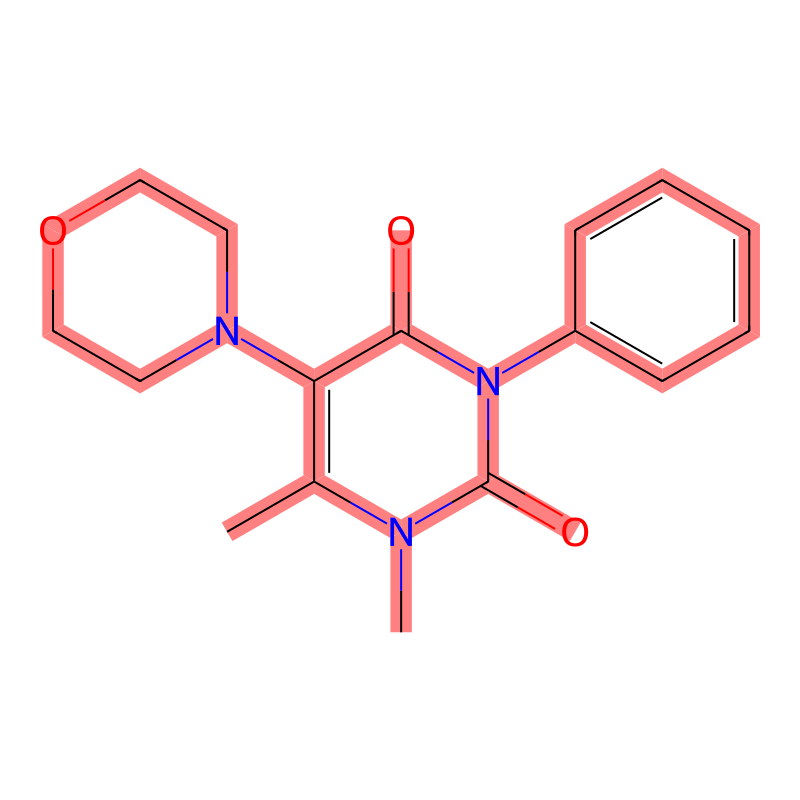

In [6]:
img, bond_importance = draw_gnn_explanation(
    "Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1",
    expl_result,
)

display(img)

In [16]:
import numpy as np
import torch
from rdkit import Chem
from rdkit.Chem import Draw


def get_important_bonds(
    mol,
    edge_index,
    edge_mask,
    threshold=0.5,
):
    edge_mask = edge_mask.detach().cpu().numpy()
    edge_index = edge_index.detach().cpu()

    bond_values = {}

    for i, importance in enumerate(edge_mask):
        src = int(edge_index[0, i])
        dst = int(edge_index[1, i])

        bond = mol.GetBondBetweenAtoms(src, dst)

        if bond is None:
            continue

        bond_idx = bond.GetIdx()

        if bond_idx not in bond_values:
            bond_values[bond_idx] = []

        bond_values[bond_idx].append(float(importance))

    bond_importance = {
        bond_idx: np.mean(values)
        for bond_idx, values in bond_values.items()
    }

    important_bonds = [
        bond_idx
        for bond_idx, importance in bond_importance.items()
        if importance >= threshold
    ]

    return important_bonds, bond_importance

def make_explanation_subgraph(mol, important_bonds):
    """
    Create an RDKit molecule containing only the atoms and bonds
    belonging to the selected explanation subgraph.
    """

    rw_mol = Chem.RWMol()

    # Atoms involved in important bonds
    important_atoms = set()

    for bond_idx in important_bonds:
        bond = mol.GetBondWithIdx(bond_idx)

        important_atoms.add(bond.GetBeginAtomIdx())
        important_atoms.add(bond.GetEndAtomIdx())

    # Map original atom indices -> new atom indices
    atom_mapping = {}

    for atom_idx in sorted(important_atoms):
        new_idx = rw_mol.AddAtom(
            Chem.Atom(mol.GetAtomWithIdx(atom_idx).GetSymbol())
        )
        atom_mapping[atom_idx] = new_idx

    # Add selected bonds
    for bond_idx in important_bonds:

        bond = mol.GetBondWithIdx(bond_idx)

        begin = atom_mapping[bond.GetBeginAtomIdx()]
        end = atom_mapping[bond.GetEndAtomIdx()]

        rw_mol.AddBond(
            begin,
            end,
            bond.GetBondType()
        )

    subgraph = rw_mol.GetMol()
    Chem.SanitizeMol(subgraph)

    return subgraph


def draw_explanation_subgraph(
    smiles,
    edge_index,
    edge_mask,
    threshold=0.5,
    size=(800, 800),
):

    mol = Chem.MolFromSmiles(smiles)

    important_bonds, bond_importance = get_important_bonds(
        mol,
        edge_index,
        edge_mask,
        threshold=threshold,
    )

    subgraph = make_explanation_subgraph(
        mol,
        important_bonds,
    )

    img = Draw.MolToImage(
        subgraph,
        size=size,
    )

    return img, bond_importance

In [19]:
edge_idx-1

tensor([[ 0,  1,  1,  2,  1, 14,  2,  3,  2,  4,  4,  5,  4, 11,  5,  6,  5, 10,
          6,  7,  7,  8,  8,  9,  9, 10, 11, 12, 11, 13, 13, 14, 13, 16, 14, 15,
         16, 17, 16, 21, 17, 18, 18, 19, 19, 20, 20, 21],
        [ 1,  0,  2,  1, 14,  1,  3,  2,  4,  2,  5,  4, 11,  4,  6,  5, 10,  5,
          7,  6,  8,  7,  9,  8, 10,  9, 12, 11, 13, 11, 14, 13, 16, 13, 15, 14,
         17, 16, 21, 16, 18, 17, 19, 18, 20, 19, 21, 20]])

In [20]:
from grover_adapter import grover_to_pyg

edge_idx = grover_to_pyg(b2a, b2revb)
edge_idx = edge_idx[:, 1:]-1

img, bond_importance = draw_explanation_subgraph(
    smiles,
    edge_idx,
    expl_result,
    threshold=0.5,
)

display(img)

[17:11:31] non-ring atom 1 marked aromatic


AtomKekulizeException: non-ring atom 1 marked aromatic

In [11]:
_, batch, features_batch, mask, targets = next(iter(data_loader))
f_atoms, f_bonds, a2b, b2a, b2revb, a_scope, b_scope, a2a = batch

In [2]:
import os 
import torch
os.chdir("/home/mabarr/gnnexplainer/")
from grover_adapter import model_data_preparation, GROVERExplainer
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from torch.utils.data import DataLoader
from grover.data import MolCollator
from grover.data import MoleculeDataset
from grover.model.models import GroverFinetuneTask
import os
os.chdir("/home/mabarr/TCruzi_pipeline/external/grover/")
from task.train import load_data
os.chdir("/home/mabarr/TCruzi_pipeline/")
from argparse import Namespace

args = Namespace(
    data_path="external/grover/solubility_data/solubility_data_categorized.csv",
    save_dir="model_nofeatures_category",
    checkpoint_dir = "model_nofeatures_category",
    checkpoint_paths = ["model_nofeatures_category/fold_0/model_0/model.pt"],
    dataset_type="classification",
    split_type="scaffold_balanced",
    split_sizes=[0.7, 0.15, 0.15],
    metric="accuracy",
    ensemble_size=1,
    num_folds=1,
    ffn_hidden_size=200,
    batch_size=1,
    epochs=60,
    init_lr=0.00015,
    self_attention=True,
    save_smiles_splits=True,
    use_wandb=True,
    wandb_entity="mariabar",
    num_workers=0,
    dropout=0.1,
    ffn_num_layers=1,
    features_path = None,
    max_data_size = None,
    use_compound_names = None,
    seed = 0,
    separate_test_path = None,
    separate_val_path = None,
    folds_file = None,
    val_fold_index = None,
    test_fold_index = None,
    features_scaling=False,
    bond_drop_rate = 0,
    no_cache = True,
    cuda = True,
    features_only=False,
    embedding_output_type = "atom",
)

debug = info = print
logger = None

model, data_loader = model_data_preparation(
    current_args=args, 
    checkpoint_path="/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt",
    smiles = ["Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1"]
)
_, batch, features_batch, mask, targets = next(iter(data_loader))

model.eval()
batch_preds = model(batch, features_batch)
batch_preds

/home/mabarr/miniconda3/envs/gnnexplainer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_v.act_func.weight".
Loading pretr

tensor([[0.9182]], grad_fn=<DivBackward0>)

In [3]:
import os 
import torch
os.chdir("/home/mabarr/gnnexplainer/")
from grover_adapter import model_data_preparation, GROVERExplainer
from torch.utils.data import DataLoader
from grover.data import MolCollator
from grover.data import MoleculeDataset
from grover.model.models import GroverFinetuneTask

model, data_loader = model_data_preparation(
    current_args=args, 
    checkpoint_path="/home/mabarr/TCruzi_pipeline/model_nofeatures_category/fold_0/model_0/model.pt",
    smiles = ["Cn1c(C)c(N2CCOCC2)c(=O)n(c1=O)c1ccccc1"]
)

model.eval()

explainer = GROVERExplainer(
    model=model,
    epochs=200,
    lr=0.01
)

_, batch, features_batch, mask, targets = next(iter(data_loader))
f_atoms, f_bonds, a2b, b2a, b2revb, a_scope, b_scope, a2a = batch

expl_result = explainer.forward(batch, features_batch)

Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.0.mpn_v.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_q.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.act_func.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_k.W_h.weight".
Loading pretrained parameter "grover.encoders.edge_blocks.0.heads.1.mpn_v.act_func.weight".
Loading pretr

100%|██████████| 200/200 [00:54<00:00,  3.64it/s]


In [13]:
expl_result[0][2]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1288, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1424, 0.0000, 0.0000, 0.0000,
        0.1479, 0.0000, 0.0000, 0.0000, 